# Pipeline 2 - Data download

Pipeline 1 finishes with a `.json` file writen in the AOI specifying the S2 dates that should be used for each mosaic:

Now it's time to download everything that is needed for the processing:
* S2 scene for classification
* OPERA masks
* SWOT 100m raster composition (multiple versions based on the flags)

## Imports


In [ ]:
%load_ext autoreload
%autoreload 2


OUTPUT_DIR = "/data/swot/output/curua-una"

In [101]:
from swot_toolkit.pipe2 import open_output_dir, download_opera_masks

In [117]:
aoi, s2_ids = open_output_dir(OUTPUT_DIR)

download_opera_masks(s2_ids.values(), aoi, OUTPUT_DIR)

Reading KML file: /data/swot/output/curua-una/kml/Curua-Una.kml


<Figure size 1000x1000 with 0 Axes>

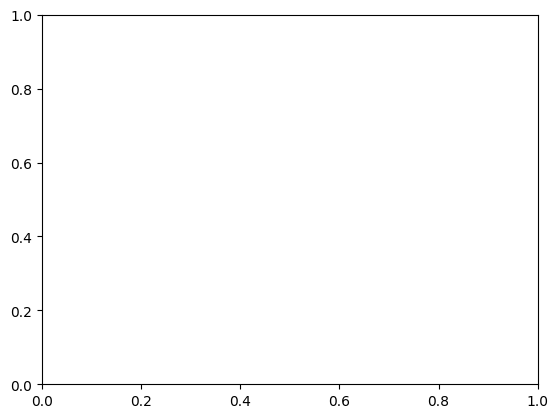

In [110]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

In [116]:
not bool(1)

False

## Download OPERA

In [40]:
import json
from pathlib import Path

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.opera import open_opera_mask, open_opera_mask_from_datetime, search_opera
from swot_toolkit.planetary import parse_s2_id
from swot_toolkit.swot import auth_earthaccess

auth_earthaccess()

output_dir = Path(OUTPUT_DIR)
assert output_dir.exists(), f"Output directory {output_dir} does not exist"  # noqa: S101

In [3]:
# Read the AOI (the first KML found in kml folder)
kml_dir = output_dir / "kml"
kml_file = kml_dir.glob("*.kml")
aoi = read_kml_geometry(next(kml_file))[0]


In [ ]:
# read the S2_IDS.json
with (output_dir / "S2_IDS.json").open("r") as f:
    s2_ids = json.load(f)


In [35]:
s2_id = next(iter(s2_ids.values()))
s2_id

'S2B_MSIL2A_20250818T135709_R067_T21MYS_20250818T172904'

In [10]:
s2_meta = parse_s2_id(s2_id)
s2_meta

{'mission': 'S2B',
 'product_level': 'L2A',
 'sensing_date': '20250818T135709',
 'processing_date': '20250818T172904',
 'relative_orbit': 67,
 'tile': '21MYS',
 'date': '20250818'}

In [81]:
opera_mask = open_opera_mask_from_datetime(
    s2_meta["tile"],
    s2_meta["sensing_date"],
    aoi,
)

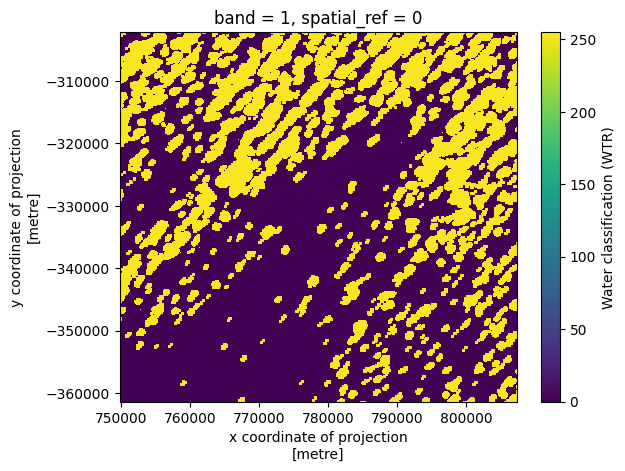

In [82]:
opera_mask.plot()

In [105]:

opera_mask

[autoreload of swot_toolkit.pipe2 failed: Traceback (most recent call last):
  File "/workspaces/swot/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/workspaces/swot/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 991, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1129, in get_code
  File "<frozen importlib._bootstrap_external>", line 1059, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/workspaces/swot/src/swot_toolkit/pipe2.py", line 73
    plot_opera_array(ax=ax, opera_mask)
                  

<xarray.DataArray (y: 1975, x: 1917)> Size: 4MB
[3786075 values with dtype=uint8]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 15kB 7.498e+05 7.499e+05 ... 8.073e+05 8.073e+05
  * y            (y) float64 16kB -3.021e+05 -3.022e+05 ... -3.614e+05
    spatial_ref  int64 8B 0
Attributes: (12/49)
    ACCODE:                                                                  ...
    AEROSOL_CLASS_REMAPPING_ENABLED:                                         ...
    AEROSOL_NOT_WATER_TO_HIGH_CONF_WATER_FMASK_VALUES:                       ...
    AEROSOL_PARTIAL_SURFACE_AGGRESSIVE_TO_HIGH_CONF_WATER_FMASK_VALUES:      ...
    AEROSOL_PARTIAL_SURFACE_WATER_CONSERVATIVE_TO_HIGH_CONF_WATER_FMASK_VALUE...
    AEROSOL_WATER_MODERATE_CONF_TO_HIGH_CONF_WATER_FMASK_VALUES:             ...
    ...                                                                          ...
    AREA_OR_POINT:                                                           ...
    scale_factor:                                                            ...
    add_offset:                                                              ...
    long_name:                                                               ...
    _FillValue:                                                              ...
    native-id:                                                               ...

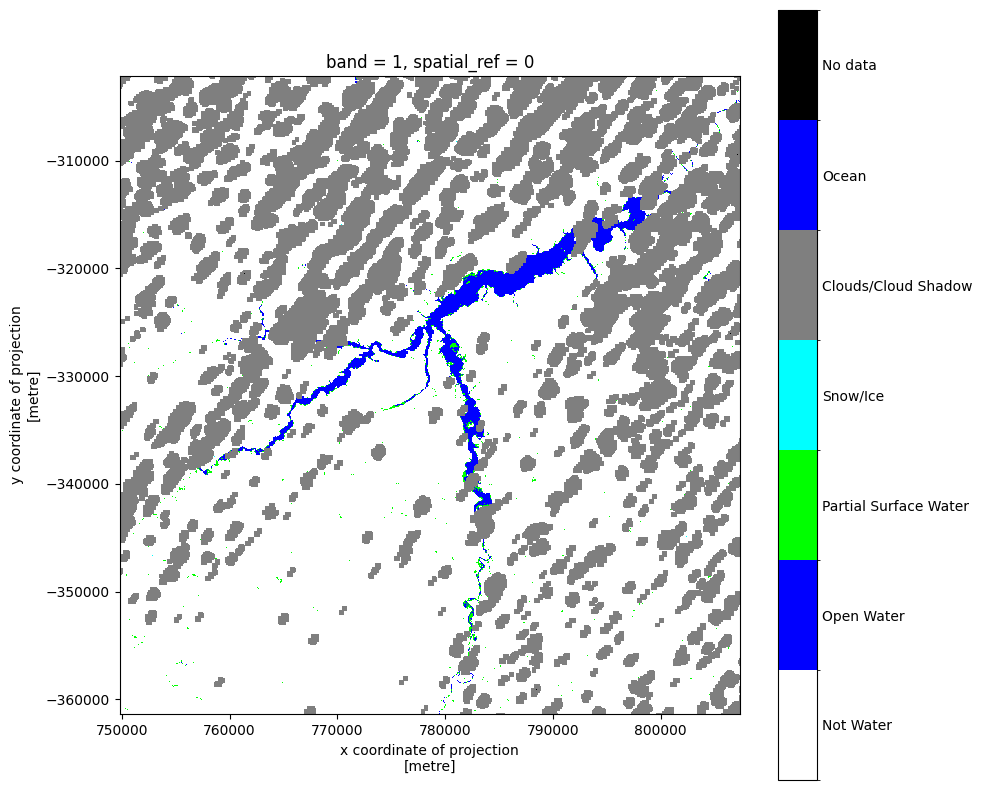

In [88]:
ax = plot_opera_array(opera_mask)
ax.set_aspect("equal")

In [91]:
results = search_opera(
    aoi.centroid, 
    (s2_meta["sensing_date"], s2_meta["processing_date"]),
)

In [93]:
opera_item = results[0]

In [97]:
opera_item["meta"]["native-id"]

'OPERA_L3_DSWx-HLS_T21MYS_20250818T135709Z_20250820T103704Z_S2B_30_v1.0'

In [99]:
opera_mask.attrs["native-id"] = opera_item["meta"]["native-id"]

In [100]:
opera_mask

<xarray.DataArray (band: 1, y: 1975, x: 1917)> Size: 4MB
[3786075 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 15kB 7.498e+05 7.499e+05 ... 8.073e+05 8.073e+05
  * y            (y) float64 16kB -3.021e+05 -3.022e+05 ... -3.614e+05
    spatial_ref  int64 8B 0
Attributes: (12/49)
    ACCODE:                                                                  ...
    AEROSOL_CLASS_REMAPPING_ENABLED:                                         ...
    AEROSOL_NOT_WATER_TO_HIGH_CONF_WATER_FMASK_VALUES:                       ...
    AEROSOL_PARTIAL_SURFACE_AGGRESSIVE_TO_HIGH_CONF_WATER_FMASK_VALUES:      ...
    AEROSOL_PARTIAL_SURFACE_WATER_CONSERVATIVE_TO_HIGH_CONF_WATER_FMASK_VALUE...
    AEROSOL_WATER_MODERATE_CONF_TO_HIGH_CONF_WATER_FMASK_VALUES:             ...
    ...                                                                          ...
    AREA_OR_POINT:                                                           ...
    scale_factor:                                                            ...
    add_offset:                                                              ...
    long_name:                                                               ...
    _FillValue:                                                              ...
    native-id:                                                               ...